In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [3]:
dataset = tf.keras.utils.image_dataset_from_directory('/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset',image_size = IMG_SIZE, batch_size = BATCH_SIZE )

Found 5415 files belonging to 4 classes.


In [4]:
print(dataset.class_names)

['Consolidation', 'Crazypaving', 'GGO', 'Negative']


In [5]:
for images, labels in dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


2026-03-14 01:28:28.538483: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
class Preprocessing:
    def __init__(self):
        pass

    def image_crop(self, image):
        h,w = image.shape[:2]
        start_x = int(w * 0.1)
        end_x = int(w * 0.9)
        start_y = int(h * 0.1)
        end_y =  int(h * 0.9)
        
        return image[start_y:end_y,start_x:end_x]

        
    def rgb_to_gray(self, image):
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    def lung_crop(self, image):
        """
        Input: image in grayscale
        Output: cropped image containing only lung region
        """
        # 1. Convert to grayscale if not already
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        
        # 2. Apply binary threshold
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
        # 3. Invert image (lungs are dark)
        thresh = cv2.bitwise_not(thresh)
    
        # 4. Find contours
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # 5. Keep the largest contour (assume lungs)
        if len(contours) == 0:
            return image  # fallback if no contour detected
    
        largest_contour = max(contours, key=cv2.contourArea)
    
        # 6. Get bounding rectangle
        x, y, w, h = cv2.boundingRect(largest_contour)
        
        # 7. Crop the image
        cropped = image[y:y+h, x:x+w]
        
        return cropped
    
    def apply_CLAHE(self, image):
        """
        Input: grayscale image
        Output: contrast-enhanced image
        """
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        return enhanced
            
        

In [18]:
scr = cv2.imread('/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/GGO/ab (12).jpg')

In [19]:
prep = Preprocessing()

In [20]:
image1 = prep.image_crop(scr)
image2 =  prep.rgb_to_gray(image1)

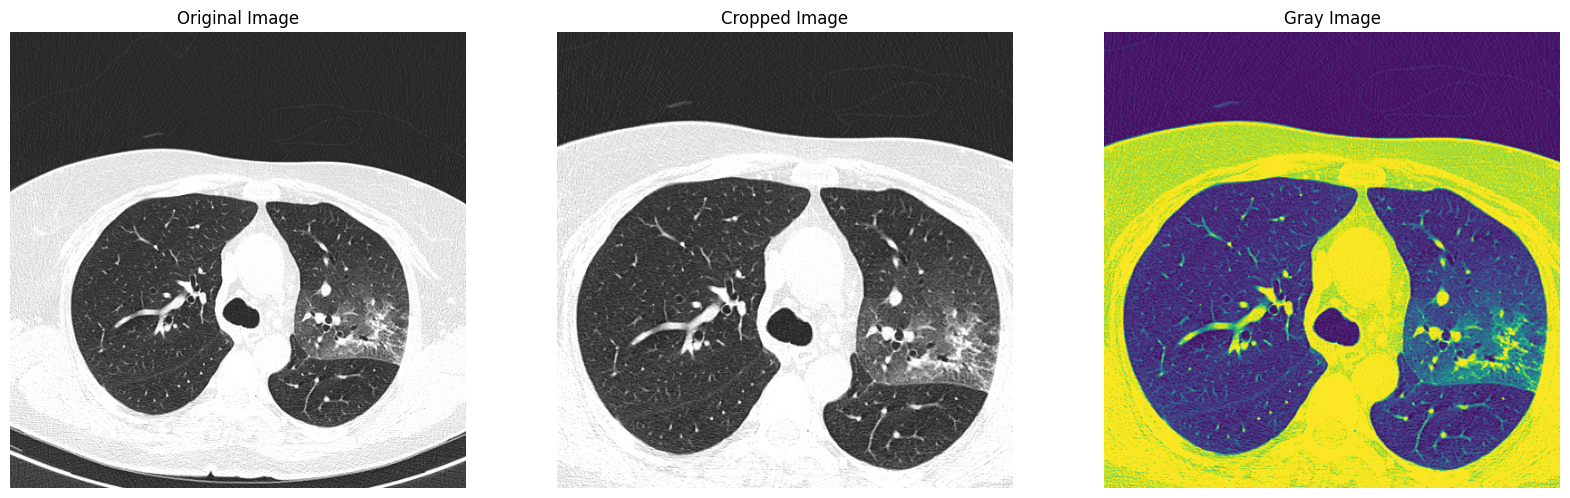

In [21]:
plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
plt.imshow(scr)
plt.title("Original Image")
plt.axis("off")  # hide axis

plt.subplot(1,3,2)
plt.imshow(image1)  # scr is your original image
plt.title("Cropped Image")
plt.axis("off")  # hide axis

plt.subplot(1,3,3)
plt.imshow(image2)  # scr is your original image
plt.title("Gray Image")
plt.axis("off")  # hide 

plt.show()

In [36]:
class AdvancedPreprocessing:
    def __init__(self):
        pass

    def lung_crop(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thresh = cv2.bitwise_not(thresh)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            return image
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        return image[y:y+h, x:x+w]

    def apply_CLAHE(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(gray)

    def remove_noise(self, image):
        return cv2.GaussianBlur(image, (5,5), 0)

    def resize_and_normalize(self, image, size=(224,224)):
        resized = cv2.resize(image, size)
        return resized / 255.0

    def preprocess(self, image):
        img = self.lung_crop(image)
        img = self.apply_CLAHE(img)
        img = self.remove_noise(img)
        img = self.resize_and_normalize(img)
        
        return img

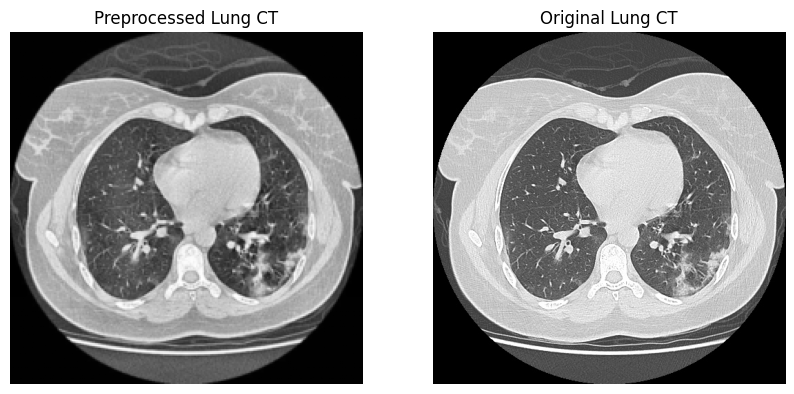

In [37]:
prep = AdvancedPreprocessing()

# Load your CT image
image = cv2.imread('/Users/rohithrk/Naruto/Projects/cnn-project/data/RawDataset/Crazypaving/c002 (21).jpg')

# Apply full preprocessing
processed_image = prep.preprocess(image)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(processed_image, cmap='gray')
plt.title("Preprocessed Lung CT")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image, cmap='gray')
plt.title("Original Lung CT")
plt.axis("off")
plt.show()

In [38]:
# Original (BGR → RGB for plotting)
orig = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Lung Crop
lung = prep.lung_crop(image)

# Step 2: CLAHE (contrast enhancement)
clahe_img = prep.apply_CLAHE(lung)

# Step 3: Denoise
denoised = prep.remove_noise(clahe_img)

# Step 4: Resize + Normalize (normalized is 0-1, convert to 0-255 for plotting)
final = prep.resize_and_normalize(denoised)
final_plot = (final * 255).astype(np.uint8)

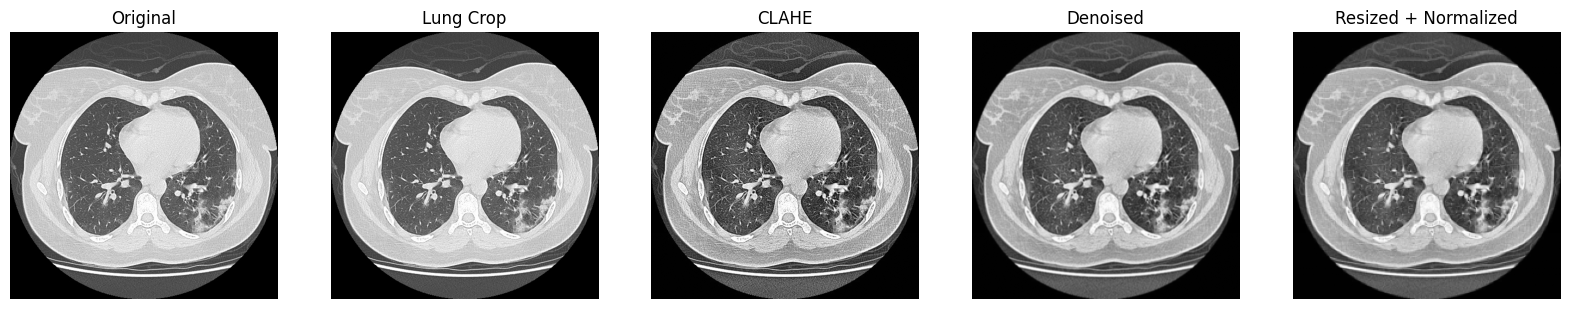

In [40]:
plt.figure(figsize=(20,5))

# Original
plt.subplot(1,5,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Lung Crop
plt.subplot(1,5,2)
plt.imshow(cv2.cvtColor(lung, cv2.COLOR_BGR2RGB))
plt.title("Lung Crop")
plt.axis("off")

# CLAHE
plt.subplot(1,5,3)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE")
plt.axis("off")

# Denoised
plt.subplot(1,5,4)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.axis("off")

# Final Resized + Normalized
plt.subplot(1,5,5)
plt.imshow(final_plot, cmap='gray')
plt.title("Resized + Normalized")
plt.axis("off")

plt.show()

In [44]:
import cv2
import numpy as np

def lung_crop_robust(image):
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    
    # Otsu threshold
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Invert so lungs are white
    thresh = cv2.bitwise_not(thresh)
    
    # Morphological operations to fill gaps
    kernel = np.ones((5,5), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return image  # fallback
    
    # Combine all large contours (lungs may be split)
    mask = np.zeros_like(gray)
    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:  # ignore small noise
            cv2.drawContours(mask, [cnt], -1, 255, -1)
    
    # Apply mask to original image
    if len(image.shape) == 3:
        result = cv2.bitwise_and(image, image, mask=mask)
    else:
        result = cv2.bitwise_and(image, mask)
    
    # Crop the bounding rectangle of the mask
    ys, xs = np.where(mask==255)
    if len(xs) == 0 or len(ys) == 0:
        return image  # fallback
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    
    cropped = result[y_min:y_max, x_min:x_max]
    return cropped

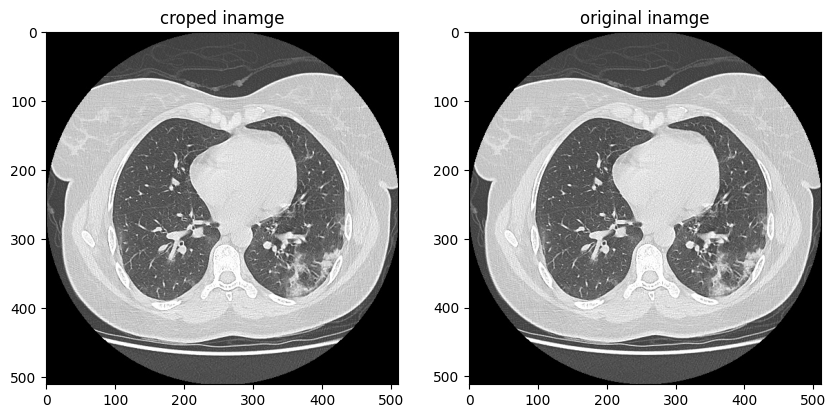

In [45]:
cropped_image =  lung_crop_robust(image)
plt.figure(figsize= (10,5))
plt.subplot(1,2,1)
plt.imshow(cropped_image)
plt.title('croped inamge')

plt.subplot(1,2,2)
plt.imshow(image)
plt.title('original inamge')
plt.show()